In [99]:
import numpy as np
import pickle as pkl
import pandas as pd
import os
import wandb
import seaborn as sns
import sys
sys.path.insert(0,'../../ML4SpatialAnalysis/')
from models.evaluation import ModelEvaluation
from datautils.dataset import SpatialCellToFeatures
from mainutils.utils import load_config


In [79]:
config = load_config('../../ML4SpatialAnalysis/configs/config.yaml')
config['model']['LOG_PATH']='../../ML4SpatialAnalysis/'+config['model']['LOG_PATH']
config['dataset']['DATA_PATH'] = '../../ML4SpatialAnalysis/'+config['dataset']['DATA_PATH']
logger = wandb.init(project=f"ML on TNBC Data", config=config, name=logname, resume=True)
dataset = SpatialCellToFeatures(config['dataset'], random_state=config['seed'])
dataset = dataset.data
logname = f"_model_{config['model']['name']}"\
				f"_graphtype_{config['dataset']['gtype']}"\
				f"_fnorm_{config['model']['fnorm']}"\
				f"_graphfeats_{config['model']['gcriterion']}"\
				f"_eval_{config['dataset']['datasplit']}"\
				f"_seed_{config['seed']}"
config['model']['eval'] = config['dataset']['datasplit']

#explainer = ModelEvaluation(config['model'],logname, logger=logger)
#explainer.run(dataset.data['test'],logname = logname)

Loading Expression Data From File


In [11]:
!wandb disabled

W&B disabled.


/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


<Axes: ylabel='Count'>

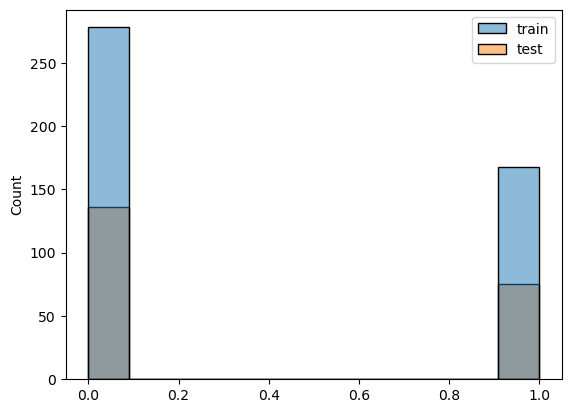

In [80]:
X_train = np.array([np.mean(x,axis = 0) for x in dataset['train']['expressions']])
y_train = np.array(dataset['train']['labels'])
X_test = np.array([np.mean(x,axis = 0) for x in dataset['test']['expressions']])
y_test = np.array(dataset['test']['labels'])
sns.histplot({'train':y_train,'test':y_test})

In [81]:
from xgboost import XGBClassifier
boosting = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=.01, objective='binary:logistic', device="cuda",min_split_loss = 1,reg_lambda = 1,alpha = 0,sampling_method = 'gradient_based',subsample = 0.5)
boosting.fit(X_train,y_train)


XGBClassifier(alpha=0, base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, min_split_loss=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, ...)

In [82]:
from mainutils.utils import graph_feature_vector, feature_normalisation, compute_scores
from models.trainer import ModelTrainer

In [83]:
(boosting.predict(X_test) == y_test)[y_test == 1].mean(),(boosting.predict(X_test) == y_test)[y_test == 0].mean()

(0.26666666666666666, 0.6323529411764706)

In [84]:
model = ModelTrainer(config['model'], 
							logger=logger,
							logfile=logname,
							seed=config['seed'])
model.optimise(dataset)


Fitting xgboost with split training
Metrics at ROI Level {'Train Accuracy': 0.9910313901345291, 'Train AUC': 0.9892728674203495, 'Train F1 Score': 0.9880239520958084}
Metrics at Patient Level {'Train Accuracy majority': 1.0, 'Train AUC majority': 1.0, 'Train F1 Score majority': 1.0}
Evaluating on Test Set
Metrics at ROI Level {'Test Accuracy': 0.6445497630331753, 'Test AUC': 0.6196078431372547, 'Test F1 Score': 0.5161290322580645}
Metrics at Patient Level {'Test Accuracy majority': 0.8, 'Test AUC majority': 0.7142857142857143, 'Test F1 Score majority': 0.6}


KeyError: 'tok_k_attr'

In [85]:
(model.classifier.predict(X_test) == y_test)[y_test == 1].mean(),(model.classifier.predict(X_test) == y_test)[y_test == 0].mean()

(0.08, 0.875)

In [87]:
model.evaluate(dataset['train'], mode='Train')
model.evaluate(dataset['test'], mode='Test')


Metrics at ROI Level {'Train Accuracy': 0.9910313901345291, 'Train AUC': 0.9892728674203495, 'Train F1 Score': 0.9880239520958084}
Metrics at Patient Level {'Train Accuracy majority': 1.0, 'Train AUC majority': 1.0, 'Train F1 Score majority': 1.0}
Metrics at ROI Level {'Test Accuracy': 0.6445497630331753, 'Test AUC': 0.6196078431372547, 'Test F1 Score': 0.5161290322580645}
Metrics at Patient Level {'Test Accuracy majority': 0.8, 'Test AUC majority': 0.7142857142857143, 'Test F1 Score majority': 0.6}


KeyError: 'tok_k_attr'

In [98]:
config['model']['pcriterion']

'majority'

In [94]:
y_test = np.array(dataset['test']['labels'])
(model.predict(dataset['test']) == y_test)[y_test == 1].mean(),(model.predict(dataset['test']) == y_test)[y_test == 0].mean()

(0.5333333333333333, 0.7058823529411765)

In [7]:
path0 = '../../ML4SpatialAnalysis/logs/'
model_list = os.listdir(path0)

In [10]:
with open(path0+model_list[0], 'rb') as f:
			out = pkl.load(f)

In [13]:
model = out['model']

In [18]:
with open('../../ML4SpatialAnalysis/data/processed_data_cellcell.pkl', 'rb') as f:
			data = pkl.load(f)
with open('../../ML4SpatialAnalysis/data/cellcell_processed_split.pkl', 'rb') as f:
			split = pkl.load(f)

In [17]:
data.keys()

dict_keys(['expressions', 'graphs', 'labels', 'patient', 'cell_labels', 'markers', 'celltypes'])

In [25]:
split['train']['expressions'][0].shape

(3816, 27)